# Ekspolartivna analiza podataka - EDA (Exploratory Data Analysis)

- Skup podataka je preuzet sa: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
- prvi korak u rešavanju bilo kakvog problem mašinskog učenja nakon preuzimanja podataka je analiza podataka tj. **EDA**

## Potrebne biblioteke

In [39]:
#!pip install seaborn

In [40]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import matplotlib.image as mpimg
import seaborn as sns
import random as rd

sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10

## Ucitavanje podataka

In [2]:
train_df = pd.read_csv("../data/sign_mnist_train.csv")
test_df = pd.read_csv("../data/sign_mnist_test.csv")

In [3]:
train_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179


In [4]:
test_df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,6,149,149,150,150,150,151,151,150,151,...,138,148,127,89,82,96,106,112,120,107
1,5,126,128,131,132,133,134,135,135,136,...,47,104,194,183,186,184,184,184,182,180
2,10,85,88,92,96,105,123,135,143,147,...,68,166,242,227,230,227,226,225,224,222
3,0,203,205,207,206,207,209,210,209,210,...,154,248,247,248,253,236,230,240,253,255
4,3,188,191,193,195,199,201,202,203,203,...,26,40,64,48,29,46,49,46,46,53


In [3]:
train_df.tail()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93
27454,23,179,180,180,180,182,181,182,183,182,...,108,132,170,194,214,203,197,205,209,215


## Osnovne informacije o skupu podataka

**Veličina skupa**

In [5]:
print(f"Trening skup: {train_df.shape[0]} primera, {train_df.shape[1]} kolona")

Trening skup: 27455 primera, 785 kolona


In [6]:
print(f"Test skup: {test_df.shape[0]} primera, {test_df.shape[1]} kolona")

Test skup: 7172 primera, 785 kolona


**Kolone**
- label - ciljna promenljiva, oznaka klase - znak znakovnog jezika
- pixel kolone za piksele od 1 do 784, što su pikseli slike dimenzije 28 x 28

In [5]:
train_df.columns

Index(['label', 'pixel1', 'pixel2', 'pixel3', 'pixel4', 'pixel5', 'pixel6',
       'pixel7', 'pixel8', 'pixel9',
       ...
       'pixel775', 'pixel776', 'pixel777', 'pixel778', 'pixel779', 'pixel780',
       'pixel781', 'pixel782', 'pixel783', 'pixel784'],
      dtype='object', length=785)

**Oznake ciljne promenljive**
- ciljna promenljiva uzima vrednosti od 0 do 24, tako da preskače broj 9
- u vrednostima se ne nalazi ni broj 25
- <span style="color: green;">oznake odgovaraju slovima od **A** do **Z**, tako da 0 odgovara A, a 25 odgovara Z</span>
- <span style="color: red;">po ovome se zaključuje da nema slova **J** što odgovara broju 9, kao i **Z** što odgovara broju 25</span>
- Slova J i Z su isključena iz skupa jer njihovo predstavljanje u znakovnom jeziku zahteva *pokret*, a skup sadrži *statične* snimke ruke

In [7]:
train_labels = np.sort(train_df["label"].unique())
train_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [8]:
test_labels = np.sort(test_df["label"].unique())
test_labels

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24])

In [9]:
(train_labels == test_labels).all()

np.True_

**Slova**
- mapiranje dostupnih brojeva u slova i obrnuto

In [10]:
LETTERS = [chr(ord("A") + i) for i in range(26)]
EXCLUDED_LABELS = {9, 25}  # J, Z
LABEL_TO_LETTER = {i: LETTERS[i] for i in range(26) if i not in EXCLUDED_LABELS}
LETTER_TO_LABEL = {v: k for k, v in LABEL_TO_LETTER.items()}

In [31]:
for letter in LETTERS:
    print(letter, end=' ')
print()
for key, value in LABEL_TO_LETTER.items():
    print(f'Vrednost: {key}: Slovo: {value} ')

A B C D E F G H I J K L M N O P Q R S T U V W X Y Z 
Vrednost: 0: Slovo: A 
Vrednost: 1: Slovo: B 
Vrednost: 2: Slovo: C 
Vrednost: 3: Slovo: D 
Vrednost: 4: Slovo: E 
Vrednost: 5: Slovo: F 
Vrednost: 6: Slovo: G 
Vrednost: 7: Slovo: H 
Vrednost: 8: Slovo: I 
Vrednost: 10: Slovo: K 
Vrednost: 11: Slovo: L 
Vrednost: 12: Slovo: M 
Vrednost: 13: Slovo: N 
Vrednost: 14: Slovo: O 
Vrednost: 15: Slovo: P 
Vrednost: 16: Slovo: Q 
Vrednost: 17: Slovo: R 
Vrednost: 18: Slovo: S 
Vrednost: 19: Slovo: T 
Vrednost: 20: Slovo: U 
Vrednost: 21: Slovo: V 
Vrednost: 22: Slovo: W 
Vrednost: 23: Slovo: X 
Vrednost: 24: Slovo: Y 


**Imena kolona pikseli**

In [47]:
pixel_columns = [pc for pc in train_df.columns if pc != "label"]

In [9]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27455 entries, 0 to 27454
Columns: 785 entries, label to pixel784
dtypes: int64(785)
memory usage: 164.4 MB


## Slika referentne azbuke

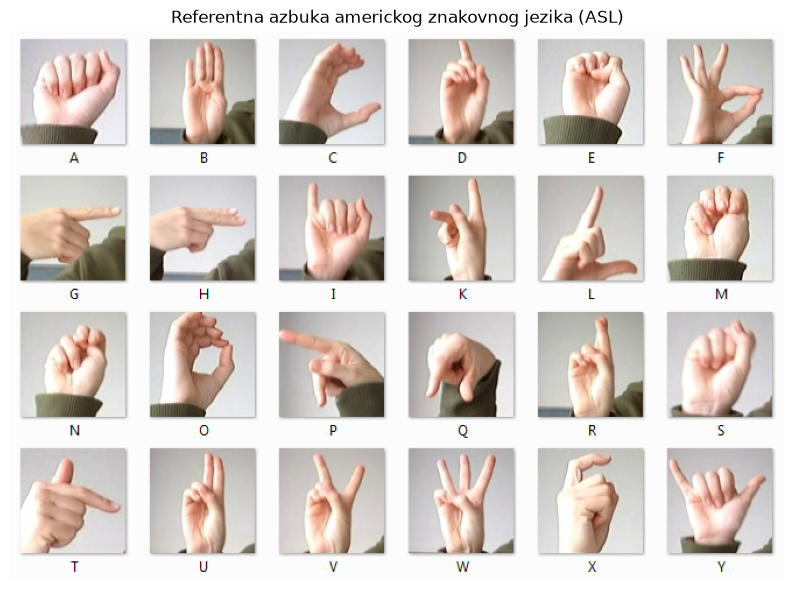

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))
ref_img = mpimg.imread("../data/amer_sign2.png")
ax.imshow(ref_img)
ax.axis("off")
ax.set_title("Referentna azbuka americkog znakovnog jezika (ASL)")
plt.show()

## Vizuelni prikaz jednog primera za svaku klasu iz trening skupa

In [50]:
def get_image(row):
    """Konvertuje red DataFrame-a (bez label kolone) u 28x28 sliku."""
    return row.values.reshape(28, 28).astype(np.uint8)

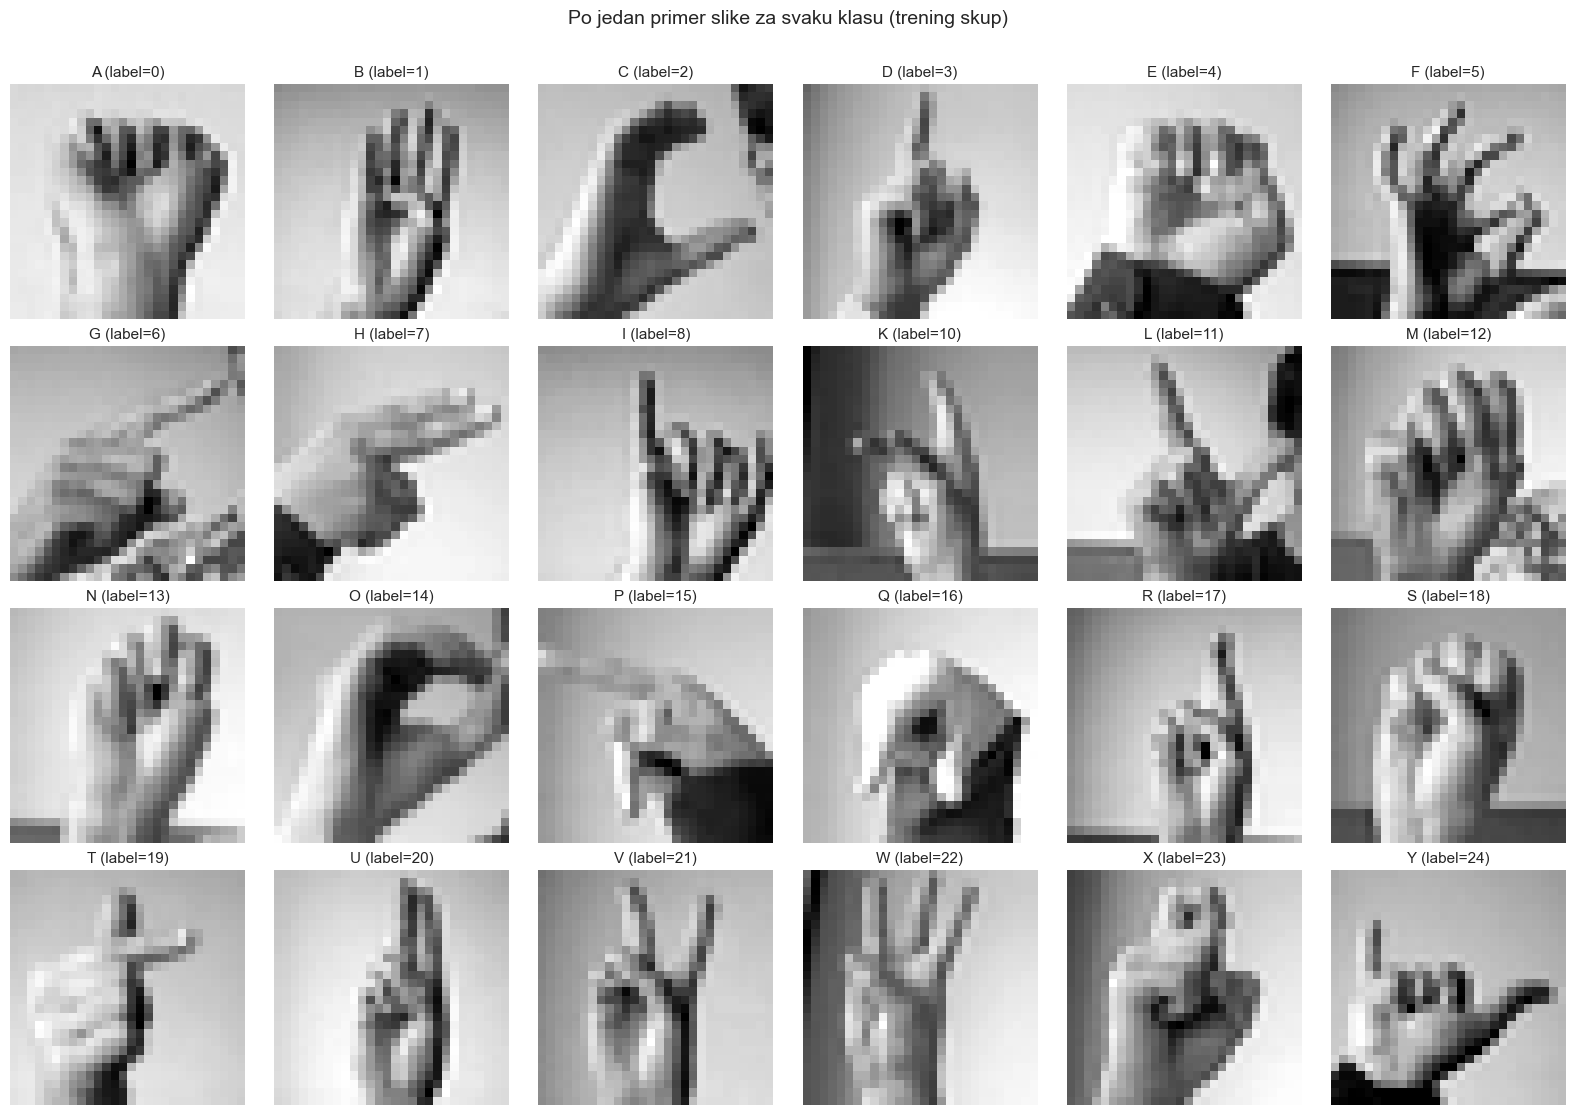

In [52]:
fig, axes = plt.subplots(4, 6, figsize=(16, 11))
axes = axes.flatten()

sorted_labels = sorted(train_df['label'].unique())
for i, label in enumerate(sorted_labels):
    sample = train_df[train_df['label'] == label].iloc[0]
    img = get_image(sample.drop('label'))
    axes[i].imshow(img, cmap='gray')
    axes[i].set_title(f"{LABEL_TO_LETTER[label]} (label={label})", fontsize=11)
    axes[i].axis('off')

plt.suptitle('Po jedan primer slike za svaku klasu (trening skup)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## Vizuelni prikaz više primera iz iste klase
- kako bi se uočila varijabilnost

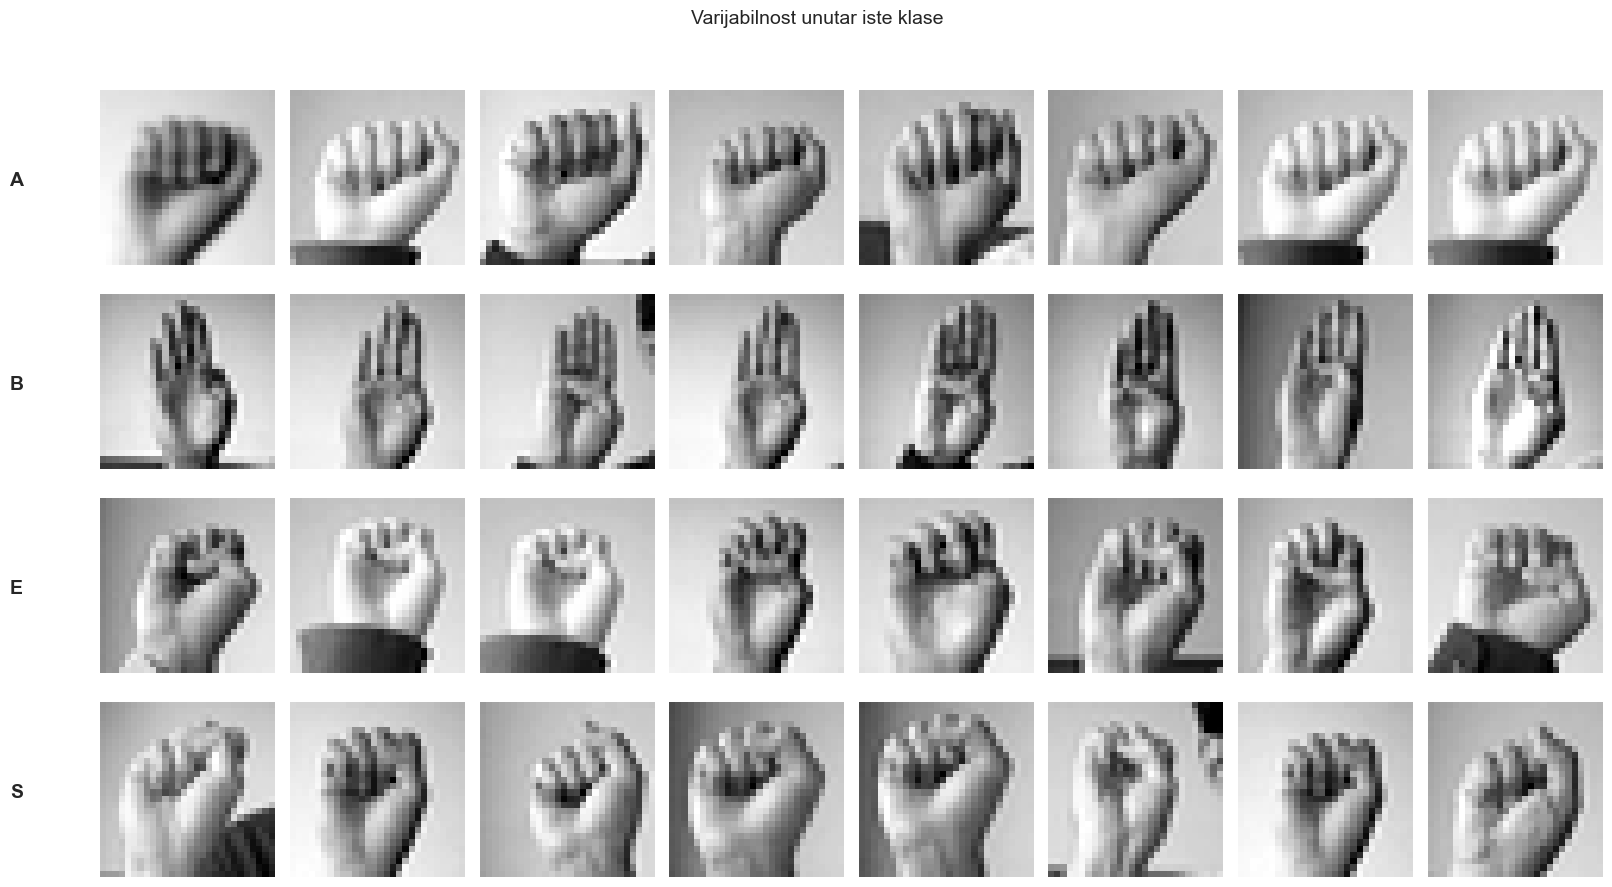

In [55]:
sample_letters = ['A', 'B', 'E', 'S']
sample_labels = [k for k, v in LABEL_TO_LETTER.items() if v in sample_letters]

fig, axes = plt.subplots(len(sample_labels), 8, figsize=(16, 2.2*len(sample_labels)))

for row_idx, label in enumerate(sample_labels):
    subset = train_df[train_df['label'] == label].sample(8, random_state=42)
    for col_idx, (_, sample) in enumerate(subset.iterrows()):
        img = get_image(sample.drop('label'))
        axes[row_idx, col_idx].imshow(img, cmap='gray')
        axes[row_idx, col_idx].axis('off')
        if col_idx == 0:
            axes[row_idx, col_idx].set_ylabel(LABEL_TO_LETTER[label], fontsize=12)
    axes[row_idx, 0].text(-15, 14, LABEL_TO_LETTER[label], fontsize=14, fontweight='bold', va='center')

plt.suptitle('Varijabilnost unutar iste klase', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

**Postoji značajna varijabilnost unutar iste klase — različiti uglovi ruke, osvetljenje i pozicioniranje**

## Vizuelno slična slova

Neka slova se oslanjaju na slične položaje šake i prstiju. Ove grupe slova predstavljaju kandidate za najčešće greške modela:
- **A, M, N, S, E** — pesnica sa palcem ispod različitog broja prstiju
- **U, V, R** — ispruženi kažiprst i srednji prst u različitim konfiguracijama
- **K, P, G** — sličan položaj šake, različita orijentacija
- **G, H** — ispruženi prsti u horizontalnom položaju

## Tipovi podataka i nedostajuće vrednosti

In [13]:
print("Tipovi podataka (trening):")
print(train_df.dtypes.value_counts())

Tipovi podataka (trening):
int64    785
Name: count, dtype: int64


In [71]:
print("\nNedostajuće vrednosti (trening):", train_df.isna().sum().sum())


Nedostajuće vrednosti (trening): 0


In [72]:
print("Nedostajuće vrednosti (test):   ", test_df.isna().sum().sum())

Nedostajuće vrednosti (test):    0


**Na ovom skupu podataka nema nedostajućih vrednosti, što olakšava proces procesiranja podataka**

## Duplikati i preklapanje trening i test skupa

In [16]:
train_dupes = train_df.duplicated().sum()
train_dupes

np.int64(0)

In [17]:
test_dupes = test_df.duplicated().sum()
test_dupes

np.int64(0)

In [18]:
train_and_test = pd.concat([train_df, test_df], ignore_index=True)

In [19]:
# duplikati u preklapanju ignorisuci duplikate u test i trening skupu
overlap = train_and_test.duplicated().sum() - (train_dupes + test_dupes)
overlap

np.int64(0)

In [20]:
print(f"Duplikati u trening skupu: {train_dupes}")
print(f"Duplikati u test skupu:    {test_dupes}")
print(f"Redovi koji se poklapaju izmedju trening i test skupa: {overlap}")

Duplikati u trening skupu: 0
Duplikati u test skupu:    0
Redovi koji se poklapaju izmedju trening i test skupa: 0


**Nema ni duplikata na ovom skupu podataka, tako da za sad nema ništa što možemo izbaciti,, tj. što nam nije od koristi ili je suvišno**

## Opseg vrednosti piksela

In [21]:
train_min, test_min = train_df[pixel_columns].values.min(), test_df[pixel_columns].values.min()
train_max, test_max = train_df[pixel_columns].values.max(), test_df[pixel_columns].values.max()

In [22]:
print(f"Trening - opseg piksela: [{train_min}, {train_max}]")
print(f"Test - opseg piksela: [{test_min}, {test_max}]")

Trening - opseg piksela: [0, 255]
Test - opseg piksela: [0, 255]


- Sve vrednosti piksela su od 0 do 255, što je očekivani opseg za piksele slika
- Nakon analize nedostajućih vrednosti, duplikata i opsega vrednosti piksela može da se zaključi da su podaci **čisti i spremni za dalju obradu**
- Skup treba **normalizovati** prilikom pripreme podataka, pre korišćenja podataka u treniranju modela

## Balansiranost klasa

In [32]:
train_counts = train_df["label"].value_counts().sort_index()
train_counts

label
0     1126
1     1010
2     1144
3     1196
4      957
5     1204
6     1090
7     1013
8     1162
10    1114
11    1241
12    1055
13    1151
14    1196
15    1088
16    1279
17    1294
18    1199
19    1186
20    1161
21    1082
22    1225
23    1164
24    1118
Name: count, dtype: int64

In [33]:
test_counts = test_df["label"].value_counts().sort_index()
test_counts

label
0     331
1     432
2     310
3     245
4     498
5     247
6     348
7     436
8     288
10    331
11    209
12    394
13    291
14    246
15    347
16    164
17    144
18    246
19    248
20    266
21    346
22    206
23    267
24    332
Name: count, dtype: int64

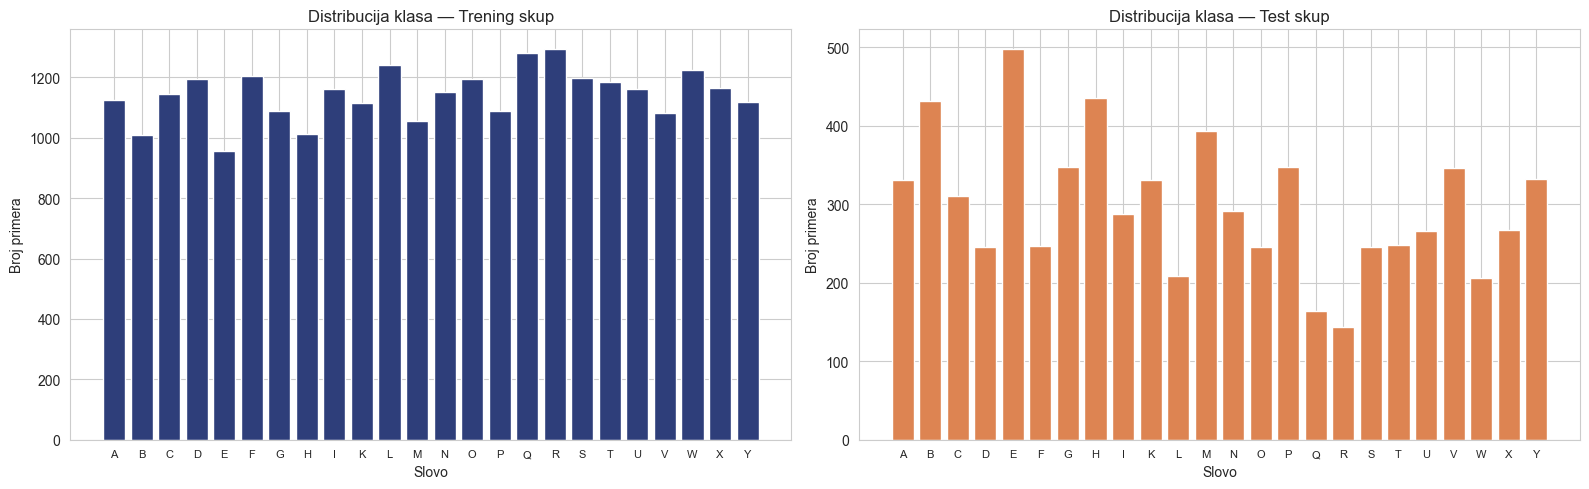

Trening: min-max broj primera po klasi: 957 - 1294
Test: min-max broj primera po klasi: 144 - 498


In [41]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, counts, title, color in zip(axes, [train_counts, test_counts], ["Trening skup", "Test skup"], ['#2e3e7a', '#DD8452']):
    letters = [LABEL_TO_LETTER[i] for i in counts.index]
    ax.bar(letters, counts.values, color=color)
    ax.set_title(f"Distribucija klasa — {title}")
    ax.set_xlabel("Slovo")
    ax.set_ylabel("Broj primera")
    ax.tick_params(axis="x", labelsize=8)

plt.tight_layout()
plt.show()

print(f"Trening: min-max broj primera po klasi: {train_counts.min()} - {train_counts.max()}")
print(f"Test: min-max broj primera po klasi: {test_counts.min()} - {test_counts.max()}")

In [43]:
print("Statistika broja primera po klasi - TRENING:")
print(f"  Min: {train_counts.min()} ({LABEL_TO_LETTER[train_counts.idxmin()]})")
print(f"  Max: {train_counts.max()} ({LABEL_TO_LETTER[train_counts.idxmax()]})")
print(f"  Prosek: {train_counts.mean():.1f}")
print(f"  Std. devijacija: {train_counts.std():.1f}")
print(f"  Koeficijent varijacije: {train_counts.std()/train_counts.mean()*100:.1f}%")

print("\nStatistika broja primera po klasi - TEST:")
print(f"  Min: {test_counts.min()} ({LABEL_TO_LETTER[test_counts.idxmin()]})")
print(f"  Max: {test_counts.max()} ({LABEL_TO_LETTER[test_counts.idxmax()]})")
print(f"  Prosek: {test_counts.mean():.1f}")
print(f"  Std. devijacija: {test_counts.std():.1f}")

Statistika broja primera po klasi - TRENING:
  Min: 957 (E)
  Max: 1294 (R)
  Prosek: 1144.0
  Std. devijacija: 83.8
  Koeficijent varijacije: 7.3%

Statistika broja primera po klasi - TEST:
  Min: 144 (R)
  Max: 498 (E)
  Prosek: 298.8
  Std. devijacija: 86.1


- Trening skup je relativno balansiran (koeficijent varijacije je nizak), što znači da ne postoji ozbiljna neravnoteža klasa
- Broj primera po klasi varira u opsegu 950-1300, a test skup je neravnomerniji (140-500)
- Nije potrebno uvoditi dodatne tehnike kojima bi morali da sintetički generišemo nove podatke (npr. *oversampling*) ili redukujemo podatke pre treniranja

## Vizuelni prikaz sličnih slova

In [44]:
similar_groups = [["A", "M", "N", "S", "E"], ["U", "V", "R"], ["K", "P", "G"], ["G", "H"]]

In [45]:
# Prikazuje jednu sliku iz df za dato slovo (A-Y, bez J). 
# index bira koji od svih primera tog slova se prikazuje (0 = prvi u skupu)
def show_letter(letter, df=train_df, index=0):
      label = LETTER_TO_LABEL[letter.upper()]
      row = df[df["label"] == label].iloc[index]
      img = row[pixel_columns].values.astype(np.uint8).reshape(28, 28)

      plt.figure(figsize=(3, 3))
      plt.imshow(img, cmap="gray")
      plt.title(f"Slovo: {letter.upper()}")
      plt.axis("off")
      plt.show()


['A', 'M', 'N', 'S', 'E']


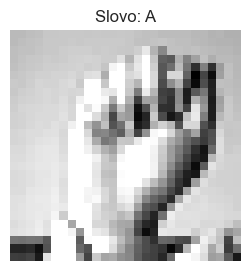

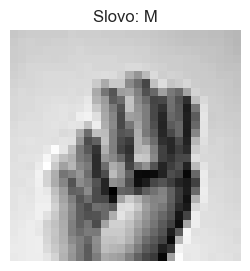

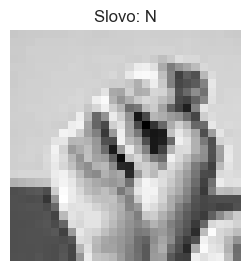

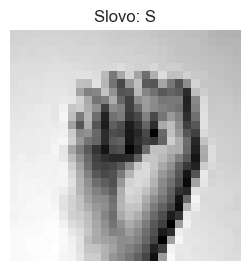

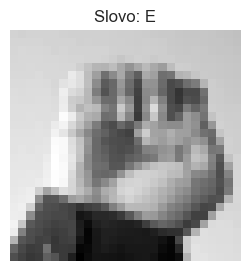

['U', 'V', 'R']


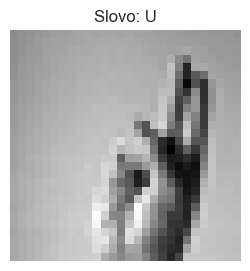

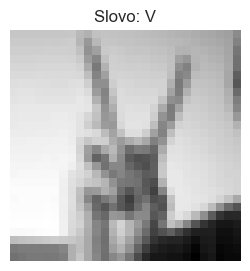

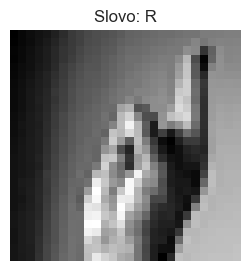

['K', 'P', 'G']


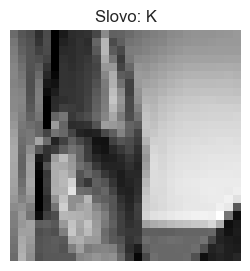

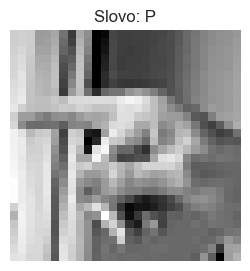

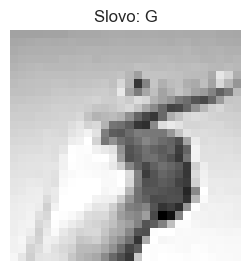

['G', 'H']


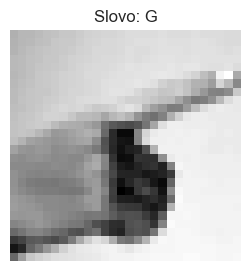

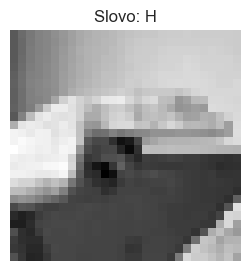

In [48]:
for group in similar_groups: 
    print(group)
    for letter in group:
        show_letter(letter, train_df, rd.randrange(0, 950))

**Ovo je ista funkcija samo radi sa subplot-ovima zbog lakše preglednosti:**

In [56]:
def show_letter(letter, df=train_df, index=0, ax=None):
    label = LETTER_TO_LABEL[letter.upper()]
    row = df[df["label"] == label].iloc[index]
    img = row[pixel_columns].values.astype(np.uint8).reshape(28, 28)

    if ax is None:
        ax = plt.gca()

    ax.imshow(img, cmap="gray")
    ax.set_title(f"Slovo: {letter.upper()}")
    ax.axis("off")

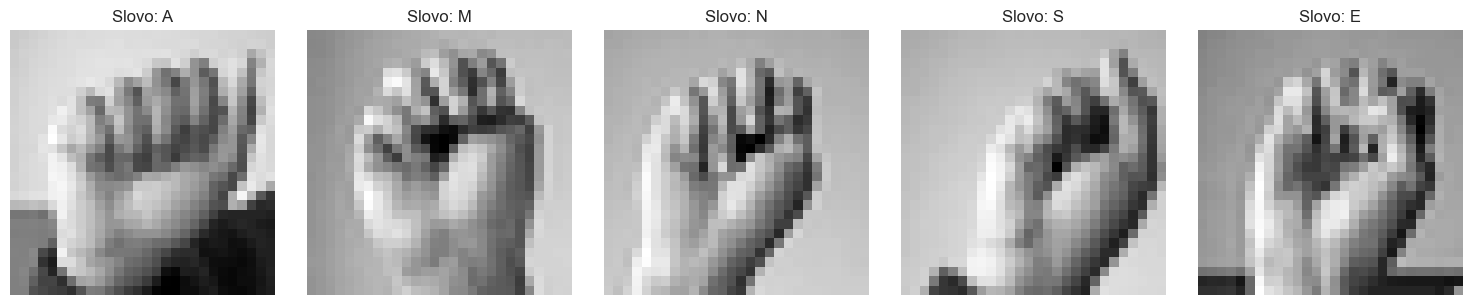

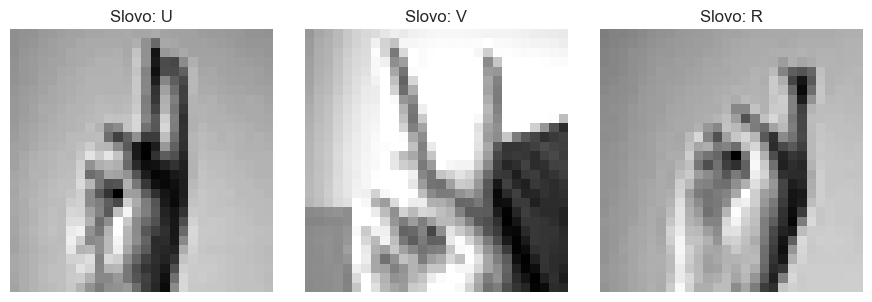

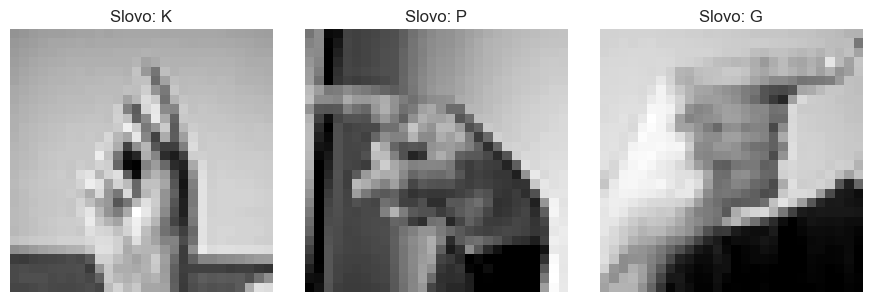

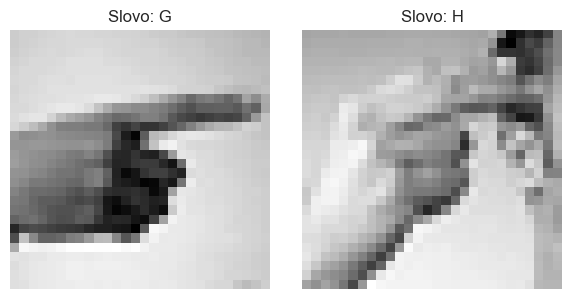

In [57]:
for group in similar_groups:
    
    fig, axes = plt.subplots(1, len(group), figsize=(3 * len(group), 3))
    
    # Ako grupa ima samo jedno slovo
    if len(group) == 1:
        axes = [axes]

    for ax, letter in zip(axes, group):
        show_letter(
            letter,
            train_df,
            rd.randrange(0, 950),
            ax=ax
        )

    plt.tight_layout()
    plt.show()

## Statistička analiza piksela

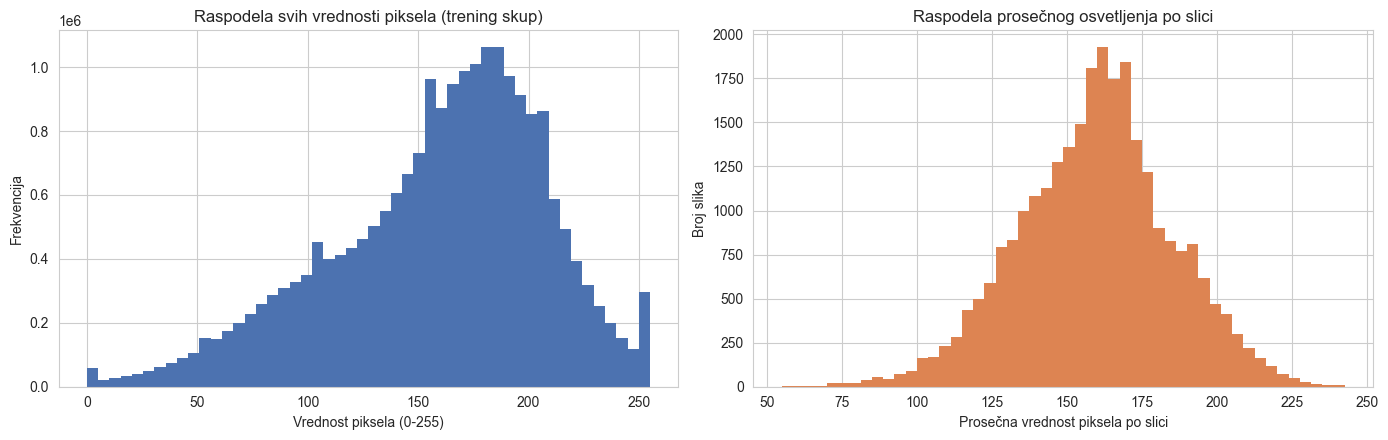

In [58]:
pixel_cols = [c for c in train_df.columns if c.startswith('pixel')]
all_pixels = train_df[pixel_cols].values.flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(all_pixels, bins=50, color='#4C72B0', edgecolor='none')
axes[0].set_title('Raspodela svih vrednosti piksela (trening skup)')
axes[0].set_xlabel('Vrednost piksela (0-255)')
axes[0].set_ylabel('Frekvencija')

row_means = train_df[pixel_cols].mean(axis=1)
axes[1].hist(row_means, bins=50, color='#DD8452', edgecolor='none')
axes[1].set_title('Raspodela prosečnog osvetljenja po slici')
axes[1].set_xlabel('Prosečna vrednost piksela po slici')
axes[1].set_ylabel('Broj slika')

plt.tight_layout()
plt.show()


In [63]:
print("Globalna statistika piksela na trening skupu:")
print(f"  Prosek:          {all_pixels.mean():.2f}")
print(f"  Std. devijacija: {all_pixels.std():.2f}")
print(f"  Medijana:        {np.median(all_pixels):.2f}")
print(f"  Min - Max:       [{all_pixels.min()} - {all_pixels.max()}]")


Globalna statistika piksela na trening skupu:
  Prosek:          159.29
  Std. devijacija: 48.77
  Medijana:        167.00
  Min - Max:       [0 - 255]


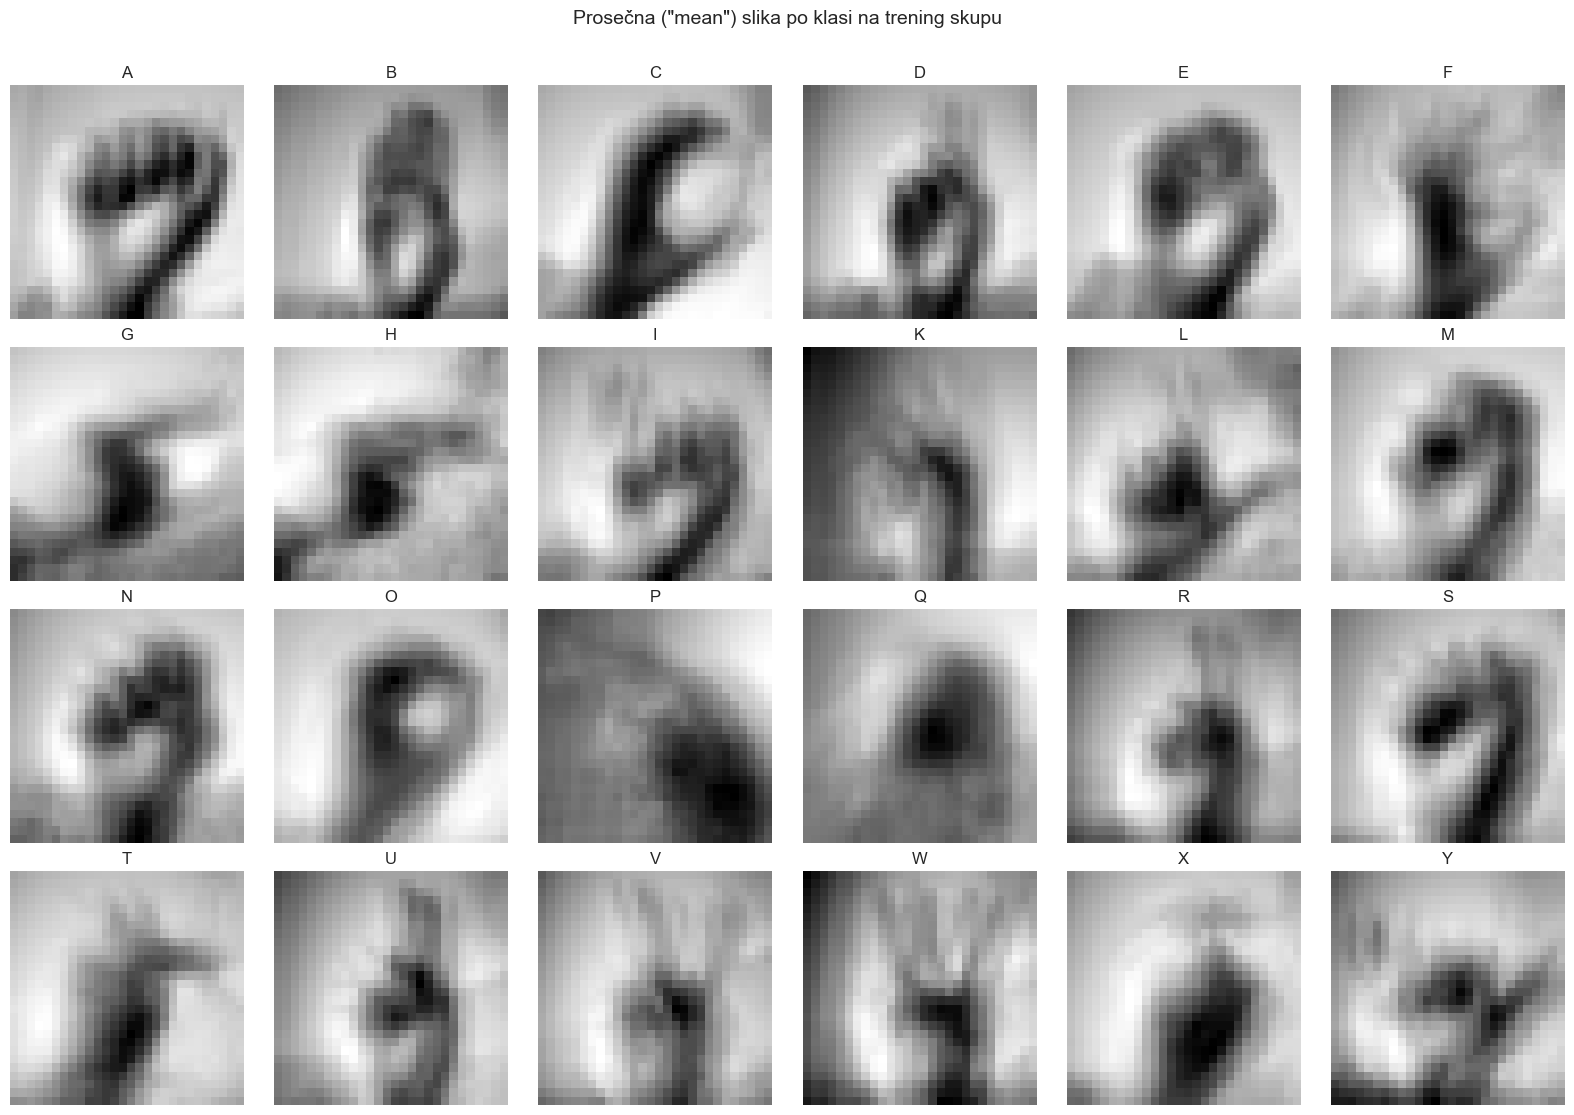

In [65]:
fig, axes = plt.subplots(4, 6, figsize=(16, 11))
axes = axes.flatten()

for i, label in enumerate(sorted_labels):
    subset = train_df[train_df['label'] == label][pixel_cols]
    mean_img = subset.mean(axis=0).values.reshape(28, 28)
    axes[i].imshow(mean_img, cmap='gray')
    axes[i].set_title(f"{LABEL_TO_LETTER[label]}", fontsize=12)
    axes[i].axis('off')

plt.suptitle('Prosečna ("mean") slika po klasi na trening skupu', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Slike kada se uproseče po klasi pokazuju prepoznatljive obrise gestova uprkos varijabilnosti unutar klase što znači da postoji konzistentan signal koji model treba da nauči**

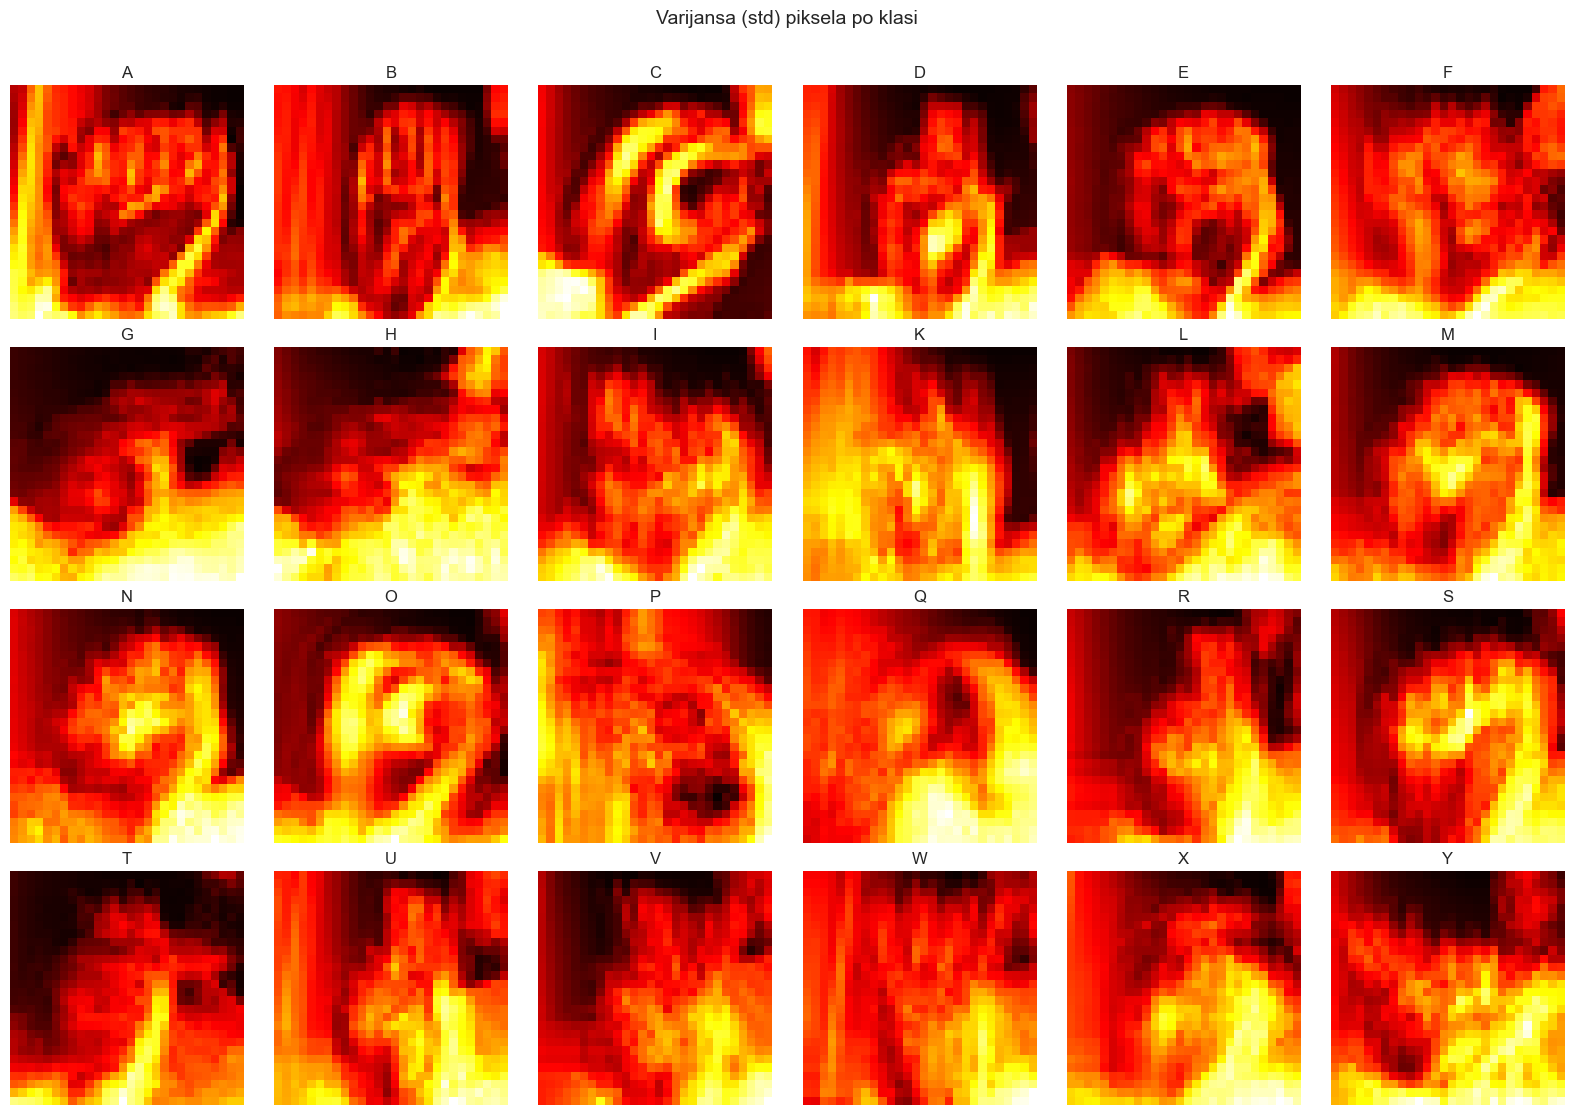

In [68]:
fig, axes = plt.subplots(4, 6, figsize=(16, 11))
axes = axes.flatten()

for i, label in enumerate(sorted_labels):
    subset = train_df[train_df['label'] == label][pixel_cols]
    std_img = subset.std(axis=0).values.reshape(28, 28)
    im = axes[i].imshow(std_img, cmap='hot')
    axes[i].set_title(f"{LABEL_TO_LETTER[label]}", fontsize=12)
    axes[i].axis('off')

plt.suptitle('Varijansa (std) piksela po klasi', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

**Što su svetlije boje one govore o većoj varijabilnosti**

**Prosečno osvetljenje i varijansa po klasi**

In [70]:
stats_per_class = train_df.groupby('label')[pixel_cols].apply(lambda x: pd.Series({
    'mean_intensity': x.values.mean(),
    'std_intensity': x.values.std()
}))
stats_per_class.index = [LABEL_TO_LETTER[i] for i in stats_per_class.index]
stats_per_class = stats_per_class.sort_values('mean_intensity')
stats_per_class

,mean_intensity,std_intensity
P,130.741417,49.670430
Q,134.375566,57.394605
K,149.818484,49.930427
C,156.042430,54.119411
O,156.898812,52.684164
F,157.876605,48.162968
H,159.106371,49.642537
W,159.553695,46.484030
G,160.464517,50.484699
A,160.600040,48.935257
